# Halo Mass Function (HMF)

This notebook explains the methods and physics for modeling the formation of dark matter halos. We compute the linear power spectrum, derive the associated mass variance $\sigma(M)$, and finally compute the Halo Mass Function $\frac{dn}{d\ln M}$ for standard and extended dark energy models.

**Contents**
1. Linear Power Spectrum and Mass Variance $\sigma^2(M)$
2. Standard Halo Mass Function ($\Lambda$CDM)
3. HMF Extended: Dark Energy Parameters ($w$CDM)


In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import toolscosmo

plt.rcParams.update({'font.size': 13, 'lines.linewidth': 2.2})


## 1. Linear Power Spectrum and Mass Variance

The mass variance $\sigma^2(M)$ characterizes the amplitude of density fluctuations on a mass scale $M$. It is the convolution of the linear power spectrum $P(k)$ with a smoothing filter (such as a top-hat or smooth-$k$ window function in Fourier space):

$$\sigma^2(R) = \int \frac{k^2 dk}{2\pi^2} P(k) \,|\tilde{W}(kR)|^2$$

First, we set up our code parameters and compute the linear power spectrum using both the full `CLASS` Boltzmann solver and the faster `CLASSemu` emulator.


Using CLASSemu to estimate linear power spectrum.
CLASSemu runtime: 0.00 s
Using CLASS to estimate linear power spectrum.
LCDM
CLASS runtime: 0.69 s


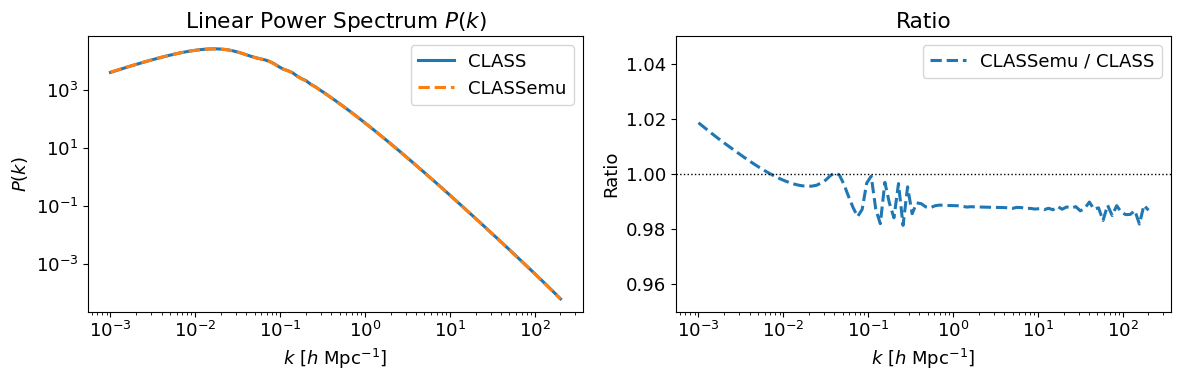

In [2]:
## set parameters
par = toolscosmo.par()
par.code.kmin = 0.001
par.code.kmax = 200
par.code.Nk   = 100
par.code.verbose = True

# Cosmology
par.cosmo.Om = 0.315
par.cosmo.Ob = 0.049
par.cosmo.As = 2.126e-09
par.cosmo.h0 = 0.673
par.cosmo.ns = 0.963
par.cosmo.Tcmb = 2.72

# Compute Linear Power Spectrum P(k)
par.file.ps = "CLASSemu"
plin_CLASSemu = toolscosmo.get_Plin(par)

par.file.ps = "CLASS"
plin_CLASS = toolscosmo.get_Plin(par)

# Compare P(k) from CLASS and CLASSemu
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
ax = axs[0]
ax.loglog(plin_CLASS['k'], plin_CLASS['P'], ls='-', label='CLASS')
ax.loglog(plin_CLASSemu['k'], plin_CLASSemu['P'], ls='--', label='CLASSemu')
ax.set_title('Linear Power Spectrum $P(k)$')
ax.set_xlabel('$k$ [$h$ Mpc$^{-1}$]')
ax.set_ylabel('$P(k)$')
ax.legend()

ax = axs[1]
ax.semilogx(plin_CLASS['k'], plin_CLASSemu['P']/plin_CLASS['P'], ls='--', label='CLASSemu / CLASS')
ax.set_title('Ratio')
ax.set_xlabel('$k$ [$h$ Mpc$^{-1}$]')
ax.set_ylabel('Ratio')
ax.set_ylim(0.95, 1.05)
ax.axhline(1.0, color='k', lw=1, ls=':')
ax.legend()

plt.tight_layout()
plt.show()


Now, we compute the mass variance $\sigma^2(M)$ directly from these power spectra and compare them.

Using CLASSemu to estimate linear power spectrum.
CLASSemu runtime: 0.00 s
Using CLASS to estimate linear power spectrum.
LCDM
CLASS runtime: 0.68 s


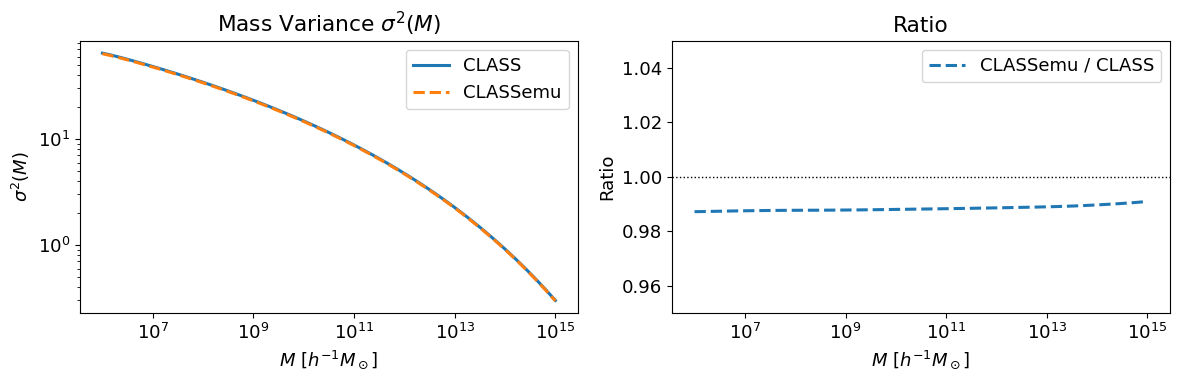

In [3]:
from scipy.interpolate import splrep, splev

def sigma_squared(M, param):
    rbin, var, dlnvardlnr = toolscosmo.variance(param)
    mbin = toolscosmo.rbin_to_mbin(rbin, param)
    tck = splrep(mbin, var)
    return splev(M, tck)

Mbins = 10**np.linspace(6, 15)

par.file.ps = "CLASSemu"
sigma2_CLASSemu = sigma_squared(Mbins, par)

par.file.ps = "CLASS"
sigma2_CLASS = sigma_squared(Mbins, par)

# Compare Mass Variances
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
ax = axs[0]
ax.loglog(Mbins, sigma2_CLASS, ls='-', label='CLASS')
ax.loglog(Mbins, sigma2_CLASSemu, ls='--', label='CLASSemu')
ax.set_title('Mass Variance $\sigma^2(M)$')
ax.set_xlabel('$M$ [$h^{-1}M_\odot$]')
ax.set_ylabel('$\sigma^2(M)$')
ax.legend()

ax = axs[1]
ax.semilogx(Mbins, sigma2_CLASSemu/sigma2_CLASS, ls='--', label='CLASSemu / CLASS')
ax.set_title('Ratio')
ax.set_xlabel('$M$ [$h^{-1}M_\odot$]')
ax.set_ylabel('Ratio')
ax.set_ylim(0.95, 1.05)
ax.axhline(1.0, color='k', lw=1, ls=':')
ax.legend()

plt.tight_layout()
plt.show()


## 2. Standard Halo Mass Function ($\Lambda$CDM)

The Halo Mass Function (HMF), denoted $\frac{dn}{d\ln M}$, describes the comoving number density of dark matter halos per logarithmic mass interval. Assuming a Sheth-Tormen or Press-Schechter formulation, it relates the mass variance directly to halo counts.

For speed in these examples, we will supply a pre-computed linear power spectrum file.


Preparing cosmological solvers...
...done


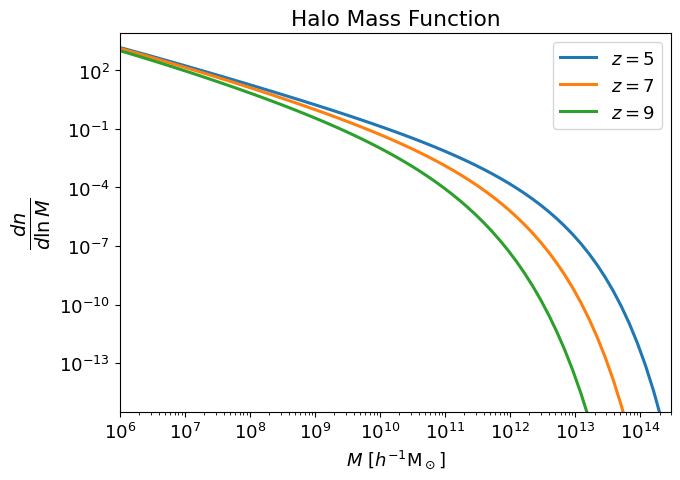

In [4]:
# Halo Mass Function parameters
par.file.ps = "../examples/CDM_Planck15_pk.dat"
par.mf.window = 'smoothk'  
par.mf.dc = 1.686          
par.mf.p  = 0.3            
par.mf.q  = 1.0            
par.mf.c  = 3.3
par.mf.beta = 4.8
par.cosmo.s8 = 0.83 

# Code grids
par.code.NM = 90
par.code.Nz = 50

ms, zs, dndlnm = toolscosmo.massfct.dndlnm(par)

zplots = [5, 7, 9]

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.set_title('Halo Mass Function')

for ii, zi in enumerate(zplots):
    ax.loglog(ms, dndlnm[np.abs(zs-zi).argmin(),:], ls='-', 
              label=f'$z={zi}$', c=f'C{ii}')

ax.axis([1e6, 3e14, 3e-16, 8e3])
ax.set_ylabel(r'$\frac{dn}{d\ln M}$', fontsize=20)
ax.set_xlabel(r'$M$ [$h^{-1}\mathrm{M}_\odot$]')
ax.legend()

plt.tight_layout()
plt.show()


## 3. HMF Extended: Dark Energy Parameters (wCDM)

The equation of state of dark energy, parameterised by $w$, influences the background expansion and the growth of structure. Here, we extend our Halo Mass Function analysis to see how different values of $w$ (in a $w$CDM setup) impact halo abundances across cosmic time.


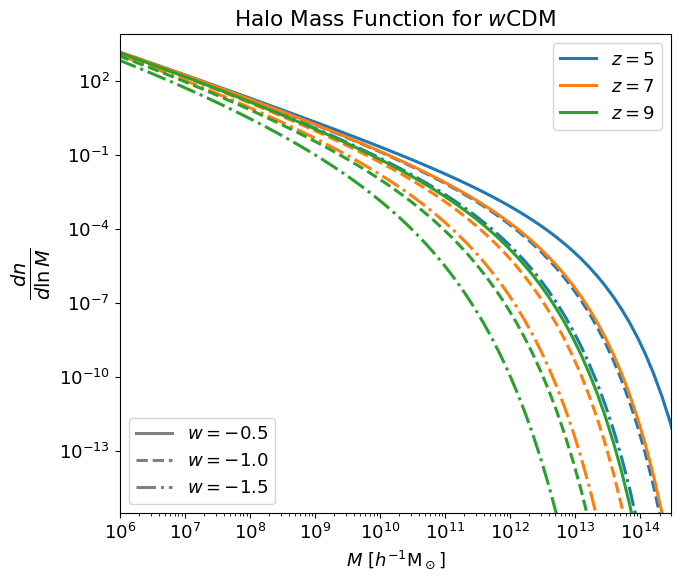

In [5]:
# Compare different w
par.DE.name = 'wcdm'

par.DE.w = -0.5
ms0, zs0, dndlnm0 = toolscosmo.massfct.dndlnm(par)

par.DE.w = -1.0
ms1, zs1, dndlnm1 = toolscosmo.massfct.dndlnm(par)

par.DE.w = -1.5
ms2, zs2, dndlnm2 = toolscosmo.massfct.dndlnm(par)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
ax.set_title('Halo Mass Function for $w$CDM')

for ii, zi in enumerate(zplots):
    ax.loglog(ms0, dndlnm0[np.abs(zs0-zi).argmin(),:], ls='-', c=f'C{ii}')
    ax.loglog(ms1, dndlnm1[np.abs(zs1-zi).argmin(),:], ls='--', c=f'C{ii}')
    ax.loglog(ms2, dndlnm2[np.abs(zs2-zi).argmin(),:], ls='-.', c=f'C{ii}')

ax.axis([1e6, 3e14, 3e-16, 8e3])
ax.set_ylabel(r'$\frac{dn}{d\ln M}$', fontsize=20)
ax.set_xlabel(r'$M$ [$h^{-1}\mathrm{M}_\odot$]')

# Craft custom legend merging both dimensions
line_labels_z = [f'$z={zi}$' for ii, zi in enumerate(zplots)]
line_colors_z = [f'C{ii}' for ii, zi in enumerate(zplots)]
legend1 = ax.legend(
    handles=[plt.Line2D([], [], color=color, linestyle='-', label=label) 
             for color, label in zip(line_colors_z, line_labels_z)],
    loc='upper right')
ax.add_artist(legend1)

line_labels_w = [f'$w={w}$' for w in [-0.5, -1.0, -1.5]]
line_styles_w = ['-', '--', '-.']
legend2 = ax.legend(
    handles=[plt.Line2D([], [], color='gray', linestyle=style, label=label) 
             for style, label in zip(line_styles_w, line_labels_w)],
    loc='lower left')

plt.tight_layout()
plt.show()
